## 7.2 핸드오프를 위한 기능 살펴보기

### 7.2.1 [실습] 핸드오프의 개념과 Command 사용법 익히기

In [ ]:
from typing import Literal
from langgraph.types import Command
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import AIMessage

def agent_1(state: MessagesState) -> Command[Literal["agent_2"]]: # [ 1 ]
    messages = AIMessage(content="1번 에이전트 메시지입니다.")
    return Command(
        goto="agent_2",
        update={"messages": [messages]}
    )

def agent_2(state: MessagesState) -> Command[Literal[END]]: # [ 2 ]
    message = AIMessage(content="2번 에이전트 메시지입니다.")
    return Command(
        goto=END,
        update={"messages": [message]},
    )

graph_builder = StateGraph(MessagesState) # [ 3 ]
graph_builder.add_node("agent_1", agent_1)
graph_builder.add_node("agent_2", agent_2)

graph_builder.add_edge(START, "agent_1")

graph = graph_builder.compile()

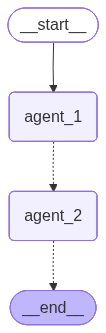

In [2]:
graph

In [3]:
for chunk in graph.stream({"messages" : []}, stream_mode="values"):
    print(chunk)

{'messages': []}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='16950b56-f4a6-4741-b942-db51d07c5395')]}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='16950b56-f4a6-4741-b942-db51d07c5395'), AIMessage(content='2번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='d6b40e80-8b51-40b8-b893-d3f8ec15ff7b')]}


### 7.2.2 [실습] 조건에 따른 Command 사용법 알아보기

In [ ]:
from typing import Literal
from langgraph.types import Command
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import AIMessage

class State(MessagesState): # [ 1 ]
    foo: str

def agent_1(state: State) -> Command[Literal["agent_2", "agent_3"]]: # [ 2 ]
    messages = AIMessage(content="1번 에이전트 메시지입니다.")
    if state["foo"] == "bar":
        return Command(
            goto="agent_3",
            update={"messages": [messages], "foo": "baz"}
        )
    return Command( # [ 3 ]
        goto="agent_2",
        update={"messages": [messages]}
    )

def agent_2(state: State): # [ 4 ]
    message = AIMessage(content="2번 에이전트 메시지입니다.")
    return Command(
        goto=END,
        update={"messages": [message]},
    )

def agent_3(state: State): # [ 5 ]
    message = AIMessage(content="3번 에이전트 메시지입니다.")
    return Command(
        goto=END,
        update={"messages": [message]},
    )

graph_builder = StateGraph(State) # [ 6 ]
graph_builder.add_node("agent_1", agent_1)
graph_builder.add_node("agent_2", agent_2)
graph_builder.add_node("agent_3", agent_3)

graph_builder.add_edge(START, "agent_1")

graph = graph_builder.compile()

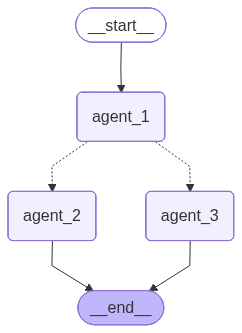

In [5]:
graph

In [6]:
for chunk in graph.stream({"messages" : [], "foo": "bar"}, stream_mode="values"):
    print(chunk)

{'messages': [], 'foo': 'bar'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='c4e5cf4b-e1d8-433b-82cf-21e50d3dd9dd')], 'foo': 'baz'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='c4e5cf4b-e1d8-433b-82cf-21e50d3dd9dd'), AIMessage(content='3번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='b12c6f88-2610-4b40-9408-4036460a8729')], 'foo': 'baz'}


In [7]:
for chunk in graph.stream({"messages" : [], "foo": "baz"}, stream_mode="values"):
    print(chunk)

{'messages': [], 'foo': 'baz'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='8698d15b-f744-4c32-b68c-5341c01c04b2')], 'foo': 'baz'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='8698d15b-f744-4c32-b68c-5341c01c04b2'), AIMessage(content='2번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='80a3dee6-8a67-47eb-bd56-e430aade01d6')], 'foo': 'baz'}
